# Distance to the training set explains most of per-allele performance

Every point is one allele under **75-fold leave-one-allele-out**: each allele is held out in
turn, so there are 75 points rather than the 16 a single supertype-stratified split gives. For
each held-out row we find the closest training row under

$$d \;=\; \mathrm{Hamming}(\text{182-aa }\texttt{hla\_seq}) \;+\; \mathrm{Hamming}(\text{9-mer peptide})$$

and average $d$ over that allele's rows. That average is the x-axis (log scale); the y-axis is
the within-allele Spearman on the held-out rows.

**Two models:**

| | |
|---|---|
| **baseline NN** | one-hot peptide + 34-aa pseudosequence &rarr; `StabilityNet` (`baseline.py`) |
| **1-NN** | no training at all — predict the mean $s$ over every training row at minimum distance |

In [10]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.rcParams.update({
    "figure.dpi": 140, "savefig.dpi": 300, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.labelsize": 12, "axes.titlesize": 13,
})
FIG = "../outputs/slides"; os.makedirs(FIG, exist_ok=True)
BLUE, GREY, RED = "#2f6fbd", "#8a8a8a", "#c0392b"

df = (pd.read_csv("../data/reference/distance_vs_spearman.csv")
        .rename(columns={"n_all": "n"}).sort_values("mean_hamming").reset_index(drop=True))
print(f"{len(df)} alleles, {df['n'].sum():,} held-out rows")
print(f"distance range {df.mean_hamming.min():.2f} - {df.mean_hamming.max():.2f}")
df.head(3)

75 alleles, 28,166 held-out rows
distance range 1.00 - 15.71


,allele,mean_hamming,mean_hla_hamming,mean_peptide_hamming,n,nn_spearman,n_nonzero,baseline_spearman
0,HLA-B*35:08,1.000000,1.000000,0.0,27,0.554013,25,0.387026
1,HLA-A*02:16,1.013405,1.013405,0.0,373,0.918447,368,0.735239
2,HLA-A*02:12,1.013441,1.013441,0.0,372,0.826880,363,0.794422


## A reusable scatter

`series` is a list of `(column, colour, label)`, so the same function draws one model or two.
The dashed line is an ordinary least-squares fit in $\log_{10}$ distance; the annotation reports
the rank correlation between distance and score, which does not assume that functional form.

In [21]:
def distance_plot(ax, d, series, title, legend_loc="lower left", annotate=True):
    """Scatter held-out Spearman against mean nearest-neighbour Hamming distance."""
    x, n = d["mean_hamming"], d["n"]
    lines = []
    for col, colour, label in series:
        y = d[col]
        ax.scatter(x, y, s=np.sqrt(n) * 3.2, c=colour, alpha=0.85, zorder=3,
                   edgecolor="white", linewidth=0.6, label=label)
        lx = np.log10(x); b, a = np.polyfit(lx, y, 1)
        xs = np.linspace(lx.min(), lx.max(), 100)
        # ax.plot(10 ** xs, a + b * xs, color=colour, lw=1.7, ls="--", alpha=0.75, zorder=2)
        # lines.append(f"{label}: $\\rho$ = {spearmanr(x, y).statistic:+.2f}, "
        #              f"mean = {y.mean():.3f}")
    ax.axhline(0, color="k", lw=0.8, alpha=0.4)
    ax.set(xscale="log", xlabel="mean Hamming distance to nearest training row",
           ylabel="held-out Spearman", title=title, ylim=(-0.45, 1.0))
    tk = [t for t in (1, 2, 3, 5, 10, 20) if x.min() * 0.75 <= t <= x.max() * 1.3]
    ax.set_xticks(tk); ax.set_xticklabels(tk)
    if annotate:
        ax.annotate("\n".join(lines), xy=(0.97, 0.96), xycoords="axes fraction",
                    ha="right", va="top", fontsize=9.5,
                    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="0.8"))
    ax.legend(frameon=False, loc=legend_loc, fontsize=9.5)
    return ax

## Plot 1 — baseline neural net

Marker area is proportional to the number of held-out measurements for that allele.

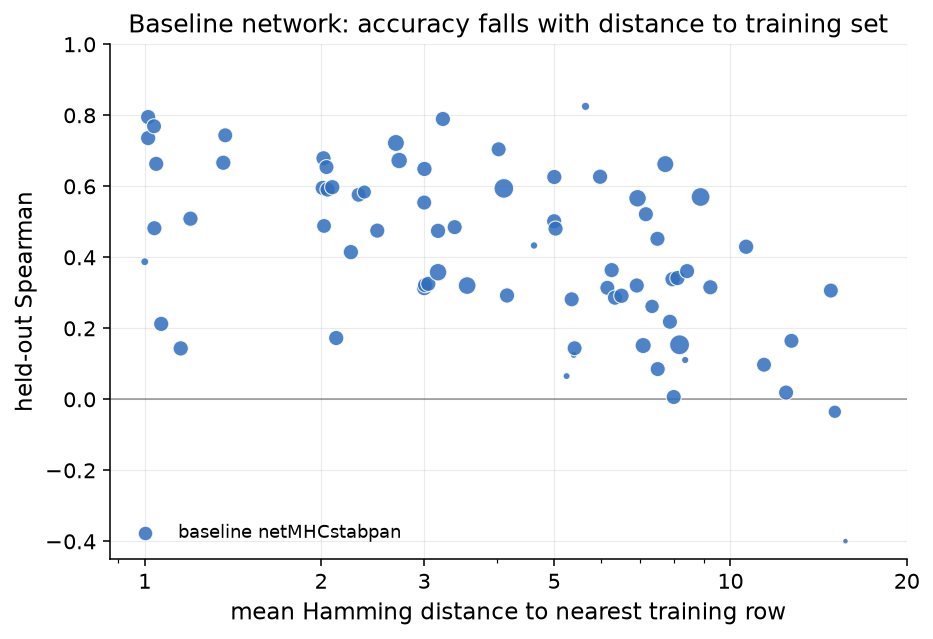

In [22]:
fig, ax = plt.subplots(figsize=(6.8, 4.7))
distance_plot(ax, df, [("baseline_spearman", BLUE, "baseline netMHCstabpan")],
              "Baseline network: accuracy falls with distance to training set")
fig.tight_layout(); fig.savefig(f"{FIG}/plot1_baseline.png", bbox_inches="tight"); plt.show()

## Plot 2 — baseline neural net and nearest neighbour together

The question this answers: **how much does training buy over simply looking up the most similar
allele-peptide pair you have already measured?**

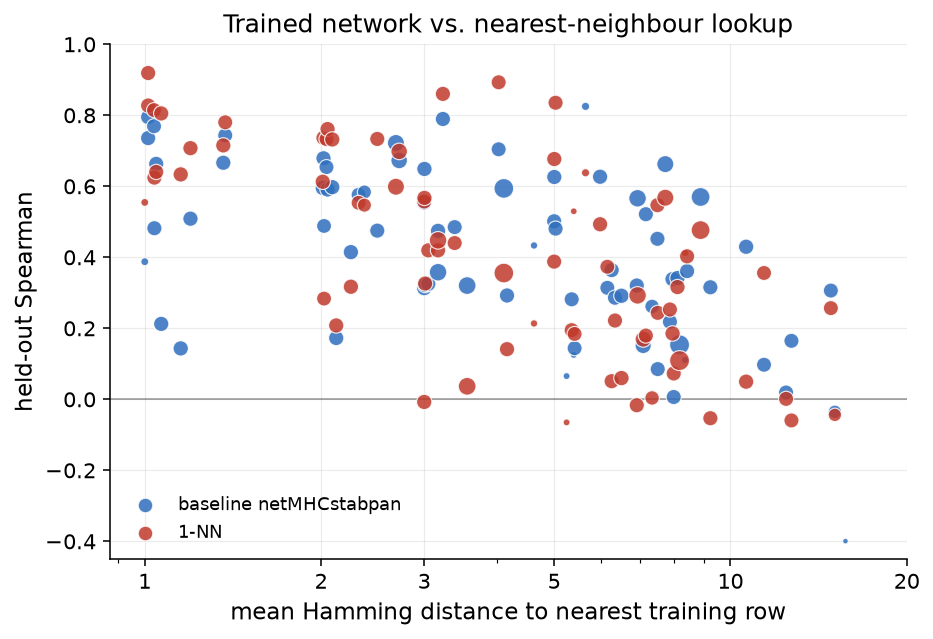

In [24]:
fig, ax = plt.subplots(figsize=(6.8, 4.7))
distance_plot(ax, df, [("baseline_spearman", BLUE, "baseline netMHCstabpan"),
                       ("nn_spearman", RED, "1-NN")],
              "Trained network vs. nearest-neighbour lookup")
fig.tight_layout(); fig.savefig(f"{FIG}/plot2_nn_and_baseline.png", bbox_inches="tight")
plt.show()

## The gap between them, directly

Both models see the same allele, so the per-allele difference is paired and carries a
confidence interval. A positive value means the network beat the lookup.

baseline NN  mean per-allele Spearman : 0.4114
1-NN         mean per-allele Spearman : 0.3936
difference   +0.0178  95% CI [-0.0278, +0.0637]  NN better on 38/75 alleles


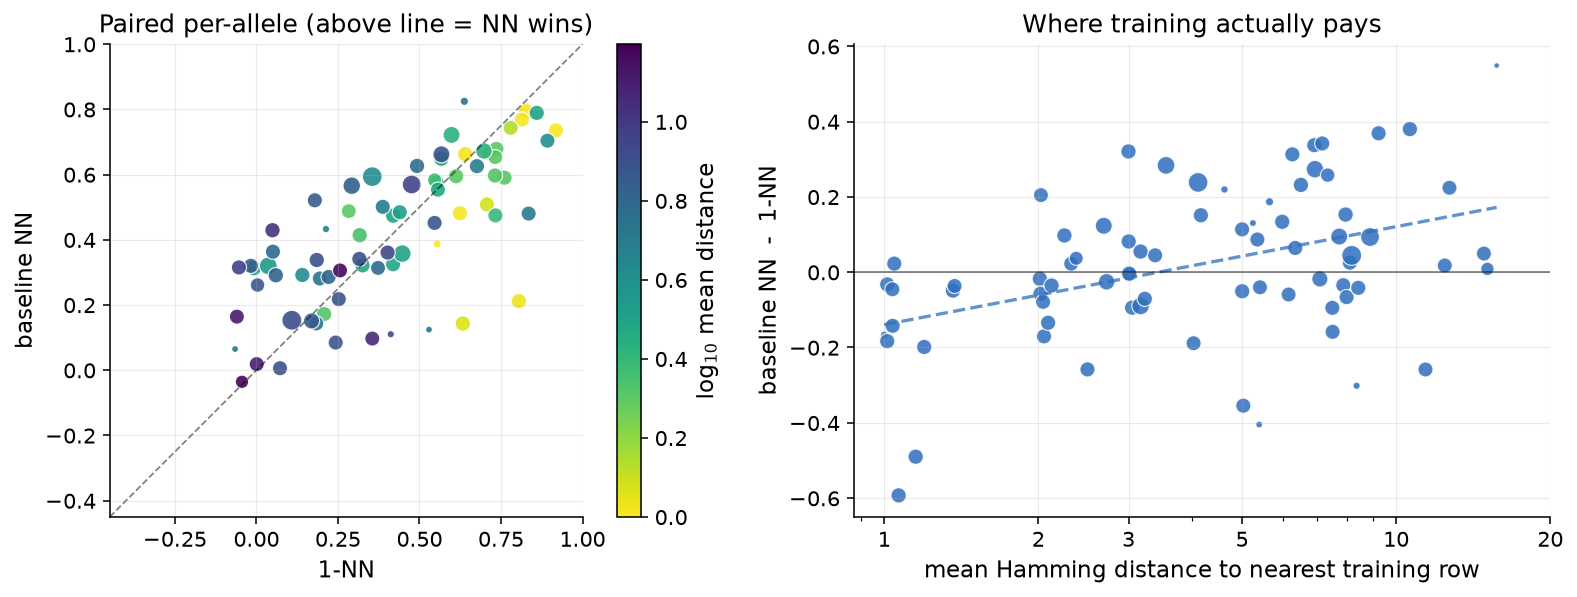

In [14]:
d = (df.baseline_spearman - df.nn_spearman).to_numpy()
rng = np.random.default_rng(0)
boot = d[rng.integers(0, len(d), (10000, len(d)))].mean(1)
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"baseline NN  mean per-allele Spearman : {df.baseline_spearman.mean():.4f}")
print(f"1-NN         mean per-allele Spearman : {df.nn_spearman.mean():.4f}")
print(f"difference   {d.mean():+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  "
      f"NN better on {(d > 0).sum()}/{len(d)} alleles")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
axes[0].scatter(df.nn_spearman, df.baseline_spearman, s=np.sqrt(df.n) * 3.2,
                c=np.log10(df.mean_hamming), cmap="viridis_r", alpha=0.9,
                edgecolor="white", linewidth=0.6)
lim = (-0.45, 1.0); axes[0].plot(lim, lim, color="k", lw=0.9, ls="--", alpha=0.5)
axes[0].set(xlim=lim, ylim=lim, xlabel="1-NN", ylabel="baseline NN",
            title="Paired per-allele (above line = NN wins)")
axes[0].set_aspect("equal")
sm = plt.cm.ScalarMappable(cmap="viridis_r",
                           norm=plt.Normalize(*np.log10(df.mean_hamming).agg(["min", "max"])))
fig.colorbar(sm, ax=axes[0]).set_label("log$_{10}$ mean distance")

axes[1].scatter(df.mean_hamming, d, s=np.sqrt(df.n) * 3.2, c=BLUE, alpha=0.85,
                edgecolor="white", linewidth=0.6)
lx = np.log10(df.mean_hamming); bb, aa = np.polyfit(lx, d, 1)
xs = np.linspace(lx.min(), lx.max(), 100)
axes[1].plot(10 ** xs, aa + bb * xs, color=BLUE, lw=1.7, ls="--", alpha=0.75)
axes[1].axhline(0, color="k", lw=0.9, alpha=0.5)
axes[1].set(xscale="log", xlabel="mean Hamming distance to nearest training row",
            ylabel="baseline NN  -  1-NN", title="Where training actually pays")
tk = [t for t in (1, 2, 3, 5, 10, 20) if df.mean_hamming.min() * .75 <= t <= df.mean_hamming.max() * 1.3]
axes[1].set_xticks(tk); axes[1].set_xticklabels(tk)
fig.tight_layout(); fig.savefig(f"{FIG}/plot3_gap.png", bbox_inches="tight"); plt.show()

## By distance tercile

         n_alleles  mean_dist     nn  baseline  NN - 1NN
tercile                                                 
near            26      1.827  0.618     0.545    -0.073
middle          24      4.556  0.401     0.432     0.031
far             25      9.306  0.153     0.252     0.099


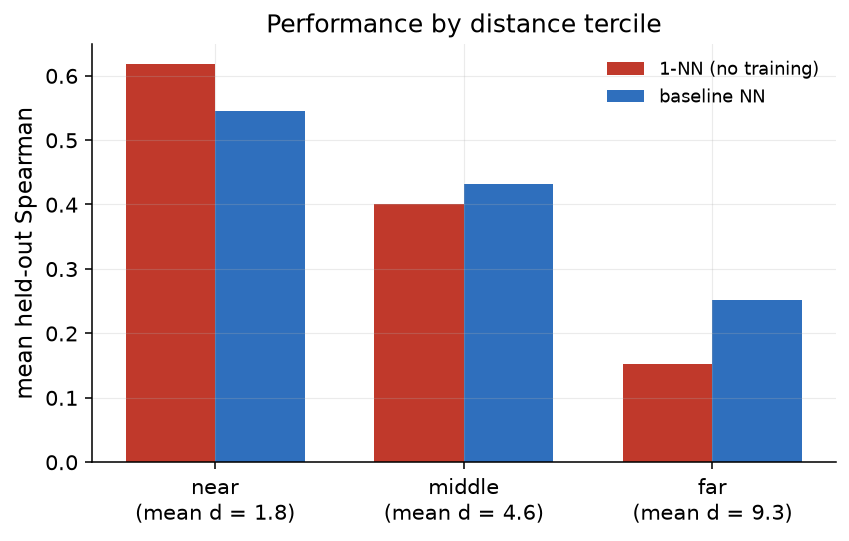

In [15]:
t = df.copy()
t["tercile"] = pd.qcut(t.mean_hamming, 3, labels=["near", "middle", "far"])
g = t.groupby("tercile", observed=True).agg(
    n_alleles=("allele", "size"), mean_dist=("mean_hamming", "mean"),
    nn=("nn_spearman", "mean"), baseline=("baseline_spearman", "mean"))
g["NN - 1NN"] = g.baseline - g.nn
print(g.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.2, 4.0))
w, xs = 0.36, np.arange(len(g))
ax.bar(xs - w / 2, g.nn, w, color=RED, label="1-NN (no training)")
ax.bar(xs + w / 2, g.baseline, w, color=BLUE, label="baseline NN")
ax.set_xticks(xs)
ax.set_xticklabels([f"{i}\n(mean d = {g.mean_dist[i]:.1f})" for i in g.index])
ax.set(ylabel="mean held-out Spearman", title="Performance by distance tercile")
ax.legend(frameon=False, fontsize=9.5)
fig.tight_layout(); fig.savefig(f"{FIG}/plot4_terciles.png", bbox_inches="tight"); plt.show()

## Reading

1. **Held-out accuracy is largely a property of the allele, not the model.** Per-allele Spearman
   falls steadily with distance to the nearest training row. The alleles the network does badly
   on are the ones with no close relative in training — so the train/test gap on the canonical
   split is weak evidence of memorisation. An unseen allele at distance 15 is a genuinely harder
   problem than one at distance 2, and no amount of regularisation changes that.
2. **A no-training lookup is close behind.** Where a near-identical allele-peptide pair has
   already been measured, copying its stability captures most of the signal, and the network's
   margin over it is thin.
3. **Training earns its keep at distance.** The gap between the two widens as the nearest
   neighbour gets further away — which is the regime that actually limits the mean, and the only
   regime where a model is doing something a database could not.